## UXM Deconvolution of Pseudobulks (Per-Split Proportions)

In this notebook, each split (train/valid/test) has its own target proportions.
Pickles are stored per-split in subdirectories and contain 4-tuples:
`(proportions, subs, uxm_data, variant)`.

### Configuration

In [20]:
import re
import numpy as np
import os
import pickle
import json
from tqdm import tqdm
from matplotlib import pyplot as plt
from syto.deconvolution.evaluation import compute_deconvolution_metrics
from syto.deconvolution.uxm import (
    load_atlas,
    uxm_deconvolution,
    rearange_uxm_deconvolution_results,
)
from edautils import plot_deconvolution_results

ios_base_path = "../Data/extended_proportions/pseudobulk/methylBert_Loyfer_205files_U25_attentionClassifier_hg38_dmr_ctype_label_mincpg_4_minlen_10_postfiltered_min_length_50_soft_labels_pooled_jakkard_no_data_leak_d041/pseudobulk/ios_deconvolution"
split_names = ["train", "valid", "test"]
variants = ["uniform", "uniform_multinomial"]

In [2]:
with open(
    "../Data/extended_proportions/pseudobulk/methylBert_Loyfer_205files_U25_attentionClassifier_hg38_dmr_ctype_label_mincpg_4_minlen_10_postfiltered_min_length_50_soft_labels_pooled_jakkard_no_data_leak_d041/pseudobulk/ios_deconvolution/train/ios_deconvolution_data_2000.pkl",
    "rb",
) as f:
    dummy_data = pickle.load(f)

In [3]:
len(dummy_data)

2000

In [4]:
[type(e) for e in dummy_data[0]]

[list, dict, dict, str]

In [5]:
dummy_data[0][-1]

'uniform_multinomial'

In [6]:
with open("../App/labels_dict.json", "rb") as f:
    labels_dict = json.load(f)
labels_dict = {int(key): value for (key, value) in labels_dict.items()}
labels_dict_reversed = {y: x for (x, y) in labels_dict.items()}

In [8]:
atlas_location = "../Data/UXM_atlas/Atlas.U25.l4.hg38.full.tsv"
atlas, ref_cells = load_atlas(atlas_location, ignore=["Megakaryocytes"])
atlas = atlas.sort_values(by=["chr", "start", "end"], ascending=True).reset_index(
    drop=True
)

### Deconvolution

Each split has its own subdirectory with pickles containing 4-tuples `(proportions, subs, uxm_data, variant)`.
`uxm_data` is a dict with a single key (the split name) mapping to `(sf, counts)`.

In [10]:
uxm_results = {(split, var): [] for split in split_names for var in variants}
target_proportions = {(split, var): [] for split in split_names for var in variants}


def sort_ios_files(files):
    """Sort ios pickle files by their numeric checkpoint index."""
    return sorted(files, key=lambda f: int(re.search(r"(\d+)\.pkl$", f).group(1)))


for split_name in split_names:
    split_dir = os.path.join(ios_base_path, split_name)
    ios_files = sort_ios_files(os.listdir(split_dir))
    print(f"Found {len(ios_files)} files in {split_dir}")

    for file in tqdm(ios_files, desc=split_name):
        with open(os.path.join(split_dir, file), "rb") as f:
            res = pickle.load(f)
        for props, subs, uxm_data, variant in res:
            sf, counts = uxm_data[split_name]
            uxm_proportions = uxm_deconvolution(
                atlas, ref_cells, sf, counts, sample_names=["pseudo_bulk_sample"]
            )[0]
            uxm_deconv_aligned = rearange_uxm_deconvolution_results(
                labels_dict_reversed, uxm_proportions, ref_cells
            )
            uxm_results[(split_name, variant)].append(uxm_deconv_aligned)
            target_proportions[(split_name, variant)].append(props)

# Convert to arrays
for key in uxm_results:
    uxm_results[key] = np.array(uxm_results[key])
    target_proportions[key] = np.array(target_proportions[key])

Found 100 files in ../Data/extended_proportions/pseudobulk/methylBert_Loyfer_205files_U25_attentionClassifier_hg38_dmr_ctype_label_mincpg_4_minlen_10_postfiltered_min_length_50_soft_labels_pooled_jakkard_no_data_leak_d041/pseudobulk/ios_deconvolution/train


train:   0%|          | 0/100 [00:00<?, ?it/s]

train: 100%|██████████| 100/100 [42:09<00:00, 25.29s/it]


Found 100 files in ../Data/extended_proportions/pseudobulk/methylBert_Loyfer_205files_U25_attentionClassifier_hg38_dmr_ctype_label_mincpg_4_minlen_10_postfiltered_min_length_50_soft_labels_pooled_jakkard_no_data_leak_d041/pseudobulk/ios_deconvolution/valid


valid: 100%|██████████| 100/100 [46:00<00:00, 27.61s/it]


Found 100 files in ../Data/extended_proportions/pseudobulk/methylBert_Loyfer_205files_U25_attentionClassifier_hg38_dmr_ctype_label_mincpg_4_minlen_10_postfiltered_min_length_50_soft_labels_pooled_jakkard_no_data_leak_d041/pseudobulk/ios_deconvolution/test


test: 100%|██████████| 100/100 [51:45<00:00, 31.06s/it]


In [11]:
for split_name in split_names:
    for var in variants:
        key = (split_name, var)

        print(
            f"{split_name}/{var}: {uxm_results[key].shape[0]} examples, "
            f"proportions shape: {target_proportions[key].shape}"
        )

train/uniform: 100000 examples, proportions shape: (100000, 39)
train/uniform_multinomial: 100000 examples, proportions shape: (100000, 39)
valid/uniform: 100000 examples, proportions shape: (100000, 39)
valid/uniform_multinomial: 100000 examples, proportions shape: (100000, 39)
test/uniform: 100000 examples, proportions shape: (100000, 39)
test/uniform_multinomial: 100000 examples, proportions shape: (100000, 39)


### Evaluation (Raw)

In [18]:
for var in variants:
    key = ("test", var)
    metrics = compute_deconvolution_metrics(uxm_results[key], target_proportions[key])
    print(f"\n=== Test metrics ({var}) ===")
    display(metrics)


=== Test metrics (uniform) ===


{'mae': 0.005569694085709042,
 'mse': 0.0002987536365786036,
 'kl': 0.14486843634282356,
 'max_error': 0.5116379563701103,
 'cosine_sim': 0.9849888316392881,
 'overall_r2': 0.9640052567727673,
 'loa_lower': -0.03387760712565771,
 'loa_upper': 0.03387760712565771,
 'loa_width': 0.06775521425131542,
 'worst_class_idx': 11,
 'worst_class_name': 11,
 'worst_class_loa_lower': -0.0696318347207261,
 'worst_class_loa_upper': 0.09678008956617293,
 'worst_class_loa_width': 0.16641192428689902,
 'per_class_loa': {'bias': array([-5.52171749e-03, -1.34041775e-03, -2.67126348e-03, -5.60969728e-04,
          1.87396806e-03,  1.01703063e-02,  5.34433986e-04,  1.16126616e-02,
          1.55859110e-03, -2.07221255e-03, -1.61641919e-03,  1.35741274e-02,
         -2.87636582e-03, -1.95289523e-03,  1.88859883e-03, -2.46238188e-04,
          5.13956332e-04, -1.14764524e-03, -6.09446296e-04, -3.56207751e-04,
         -1.30377785e-03, -4.57245437e-03, -2.56127317e-03, -9.13395247e-05,
         -1.11376168e-03


=== Test metrics (uniform_multinomial) ===


{'mae': 0.005588209650905272,
 'mse': 0.00029963279864884024,
 'kl': 0.1453778428882693,
 'max_error': 0.515108788858931,
 'cosine_sim': 0.9848859644328983,
 'overall_r2': 0.9638993326630704,
 'loa_lower': -0.03392741744423608,
 'loa_upper': 0.03392741744423608,
 'loa_width': 0.06785483488847216,
 'worst_class_idx': 11,
 'worst_class_name': 11,
 'worst_class_loa_lower': -0.0695969920734862,
 'worst_class_loa_upper': 0.09675538473073837,
 'worst_class_loa_width': 0.16635237680422457,
 'per_class_loa': {'bias': array([-5.53620835e-03, -1.34196075e-03, -2.67346815e-03, -5.65280328e-04,
          1.86755262e-03,  1.01704350e-02,  5.31580210e-04,  1.16187386e-02,
          1.55974497e-03, -2.06700008e-03, -1.60553188e-03,  1.35791963e-02,
         -2.87073592e-03, -1.94003328e-03,  1.88537000e-03, -2.47875996e-04,
          5.14826383e-04, -1.15007293e-03, -6.11324690e-04, -3.49061595e-04,
         -1.30541093e-03, -4.57637192e-03, -2.55500102e-03, -9.34303675e-05,
         -1.11555845e-03,


=== uniform ===


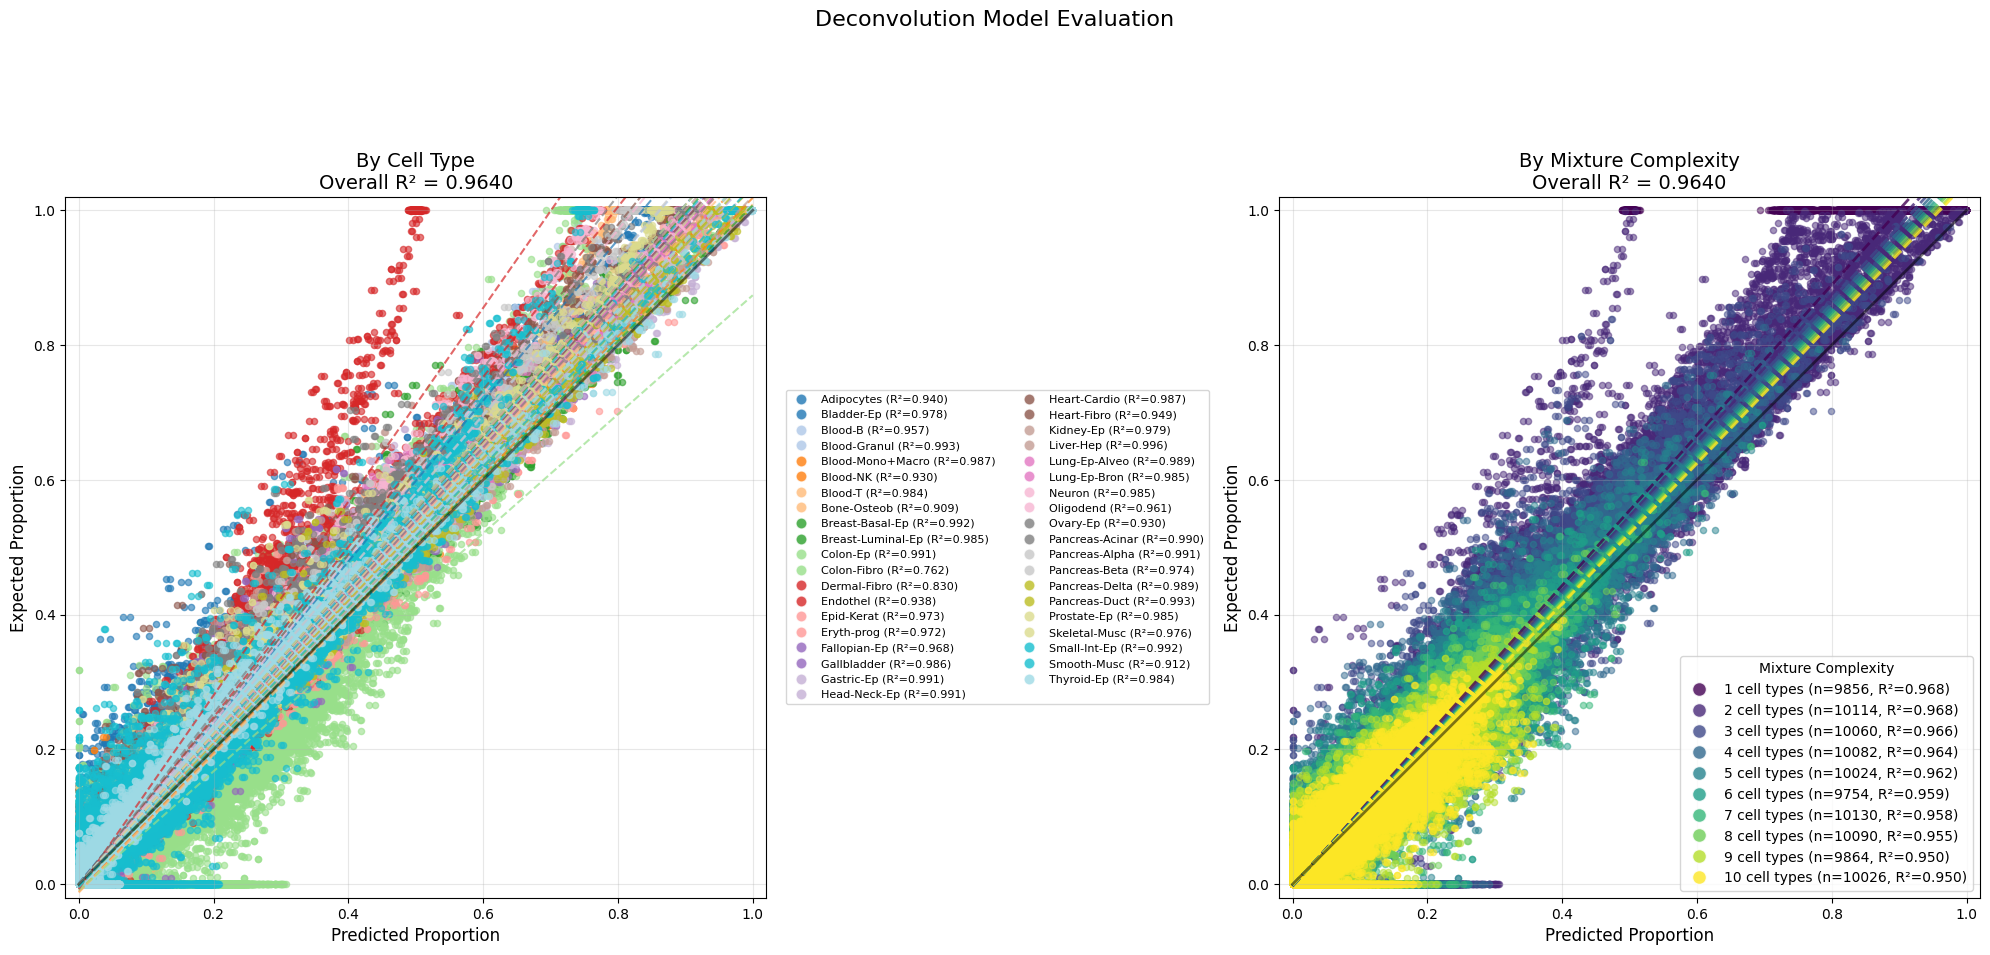


=== uniform_multinomial ===


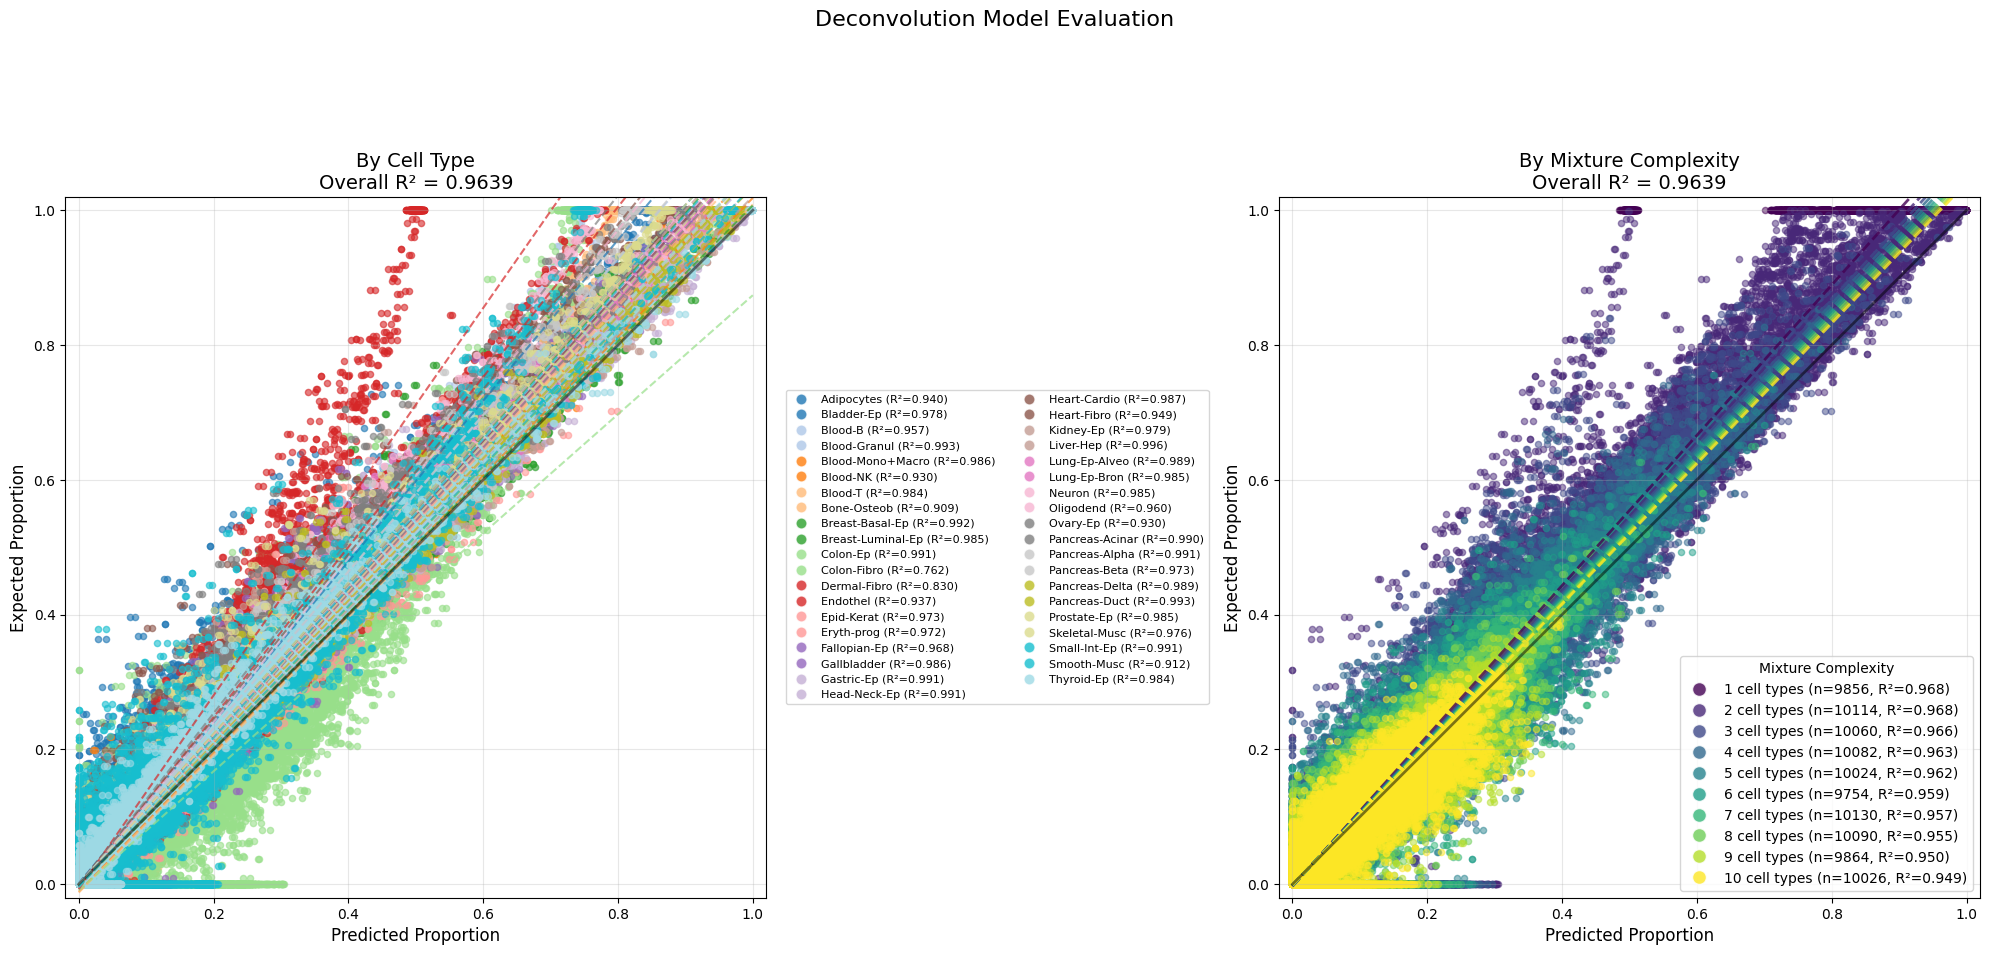

In [21]:
for var in variants:
    key = ("test", var)
    print(f"\n=== {var} ===")
    plot_deconvolution_results(
        target_proportions[key], uxm_results[key], labels_dict=labels_dict
    )
    plt.show()

### Linear Calibration

In [ ]:
from syto.deconvolution.linear_calibrator import LinearCalibrator

calibrators = {}
calibrated_test_preds = {}
for var in variants:
    calibrator = LinearCalibrator()
    calibrator.fit(uxm_results[("valid", "uniform")], target_proportions[("valid", "uniform")])
    calibrated_pred, _ = calibrator.predict(uxm_results[("test", var)])
    calibrated_pred = np.round(calibrated_pred, 4)
    calibrators[var] = calibrator
    calibrated_test_preds[var] = calibrated_pred

    display(metrics)

    metrics = compute_deconvolution_metrics(    print(f"\n=== Calibrated test metrics ({var}) ===")

        calibrated_pred, target_proportions[("test", var)]    )

In [ ]:
for var in variants:
    print(f"\n=== {var} (calibrated) ===")
    plot_deconvolution_results(
        target_proportions[("test", var)],
        calibrated_test_preds[var],
        labels_dict=labels_dict,
    )

### Save Results

In [13]:
save_path = "../Data/extended_proportions/pseudobulk/uxm"

#### Features

In [ ]:
from collections import defaultdict

features = defaultdict(lambda: defaultdict(list))

for split_name in split_names:
    split_dir = os.path.join(ios_base_path, split_name)
    os.path.makedirs(save_path, exist_ok=True)
    ios_files = sort_ios_files(os.listdir(split_dir))

    for file in tqdm(ios_files, desc=f"features {split_name}"):
        with open(os.path.join(split_dir, file), "rb") as f:
            res = pickle.load(f)
        for props, subs, uxm_data, variant in res:
            sf, counts = uxm_data[split_name]
            feat_key = f"{split_name}_{variant}"
            features[feat_key]["sf"].append(sf)
            features[feat_key]["counts"].append(counts)

# Attach per-split per-variant target proportions
for split_name in split_names:
    for var in variants:
        features[f"target_proportions_{split_name}_{var}"] = target_proportions[
            (split_name, var)
        ]


with open(os.path.join(save_path, "uxm_input_features.pkl"), "wb") as f:
    pickle.dump(dict(features), f)

#### Predictions

In [14]:
for split_name in split_names:
    for var in variants:
        key = (split_name, var)
        np.savez(
            os.path.join(save_path, f"uxm_results_{split_name}_{var}"),
            uxm_results[key],
        )
        np.savez(
            os.path.join(save_path, f"target_proportions_{split_name}_{var}"),
            target_proportions[key],
        )

In [17]:
np.all(
    target_proportions[("test", "uniform")]
    == target_proportions[("test", "uniform_multinomial")]
)

np.True_

#### Calibrator

In [ ]:
for var in variants:

    calibrators[var].save(    )
        f"{save_path}/uxm_linear_calibrator_{var}.npz"